# AI512: Artificial Intelligence
# Lab 2 — Uninformed Search
### Implementing the Five Classic Blind-Search Strategies (BFS , DFS , UCS , DLS , IDS) with Queues, Stacks, and Priority Queues



**Objective:** implement the five *uninformed* (blind) search algorithms — **BFS, DFS, UCS, DLS, and IDS** — from scratch in Python. The spine of the lab is the **data structure that drives the frontier**: BFS is powered by a **FIFO queue**, DFS by a **LIFO stack**, and UCS by a **priority queue**.

## Setup

import the two data-structure helpers used throughout the lab:
- `collections.deque` — a double-ended queue. We use it as a **FIFO queue** (BFS) and, or if wanted, as a stack.
- `heapq` — a binary-heap **priority queue**, used by UCS to always pop the cheapest node next.


In [43]:
from collections import deque
import heapq

## Shared Data — The Two Graphs



| Graph | Type | Format | Used by |
|---|---|---|---|
| `graph` | Unweighted, **undirected** | adjacency list: `node -> [neighbours]` | P1, P2, P4, P5 |
| `weighted_graph` | Weighted, **directed** | `node -> [(neighbour, cost), ...]` | P3 |

Edges of the unweighted `graph` (undirected): **A–B, A–C, B–D, B–E, C–F, E–F** &nbsp;→&nbsp; 6 nodes, 6 edges.

---

### What the two graphs look like

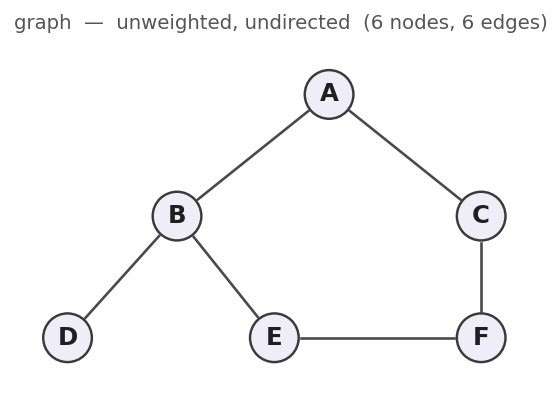

Reading it: every line is a two-way link, so `A: ['B', 'C']` means you can walk
A&nbsp;&rarr;&nbsp;B and B&nbsp;&rarr;&nbsp;A. Neighbour lists are in alphabetical
order, which is what fixes the visit order in  BFS and DFS.

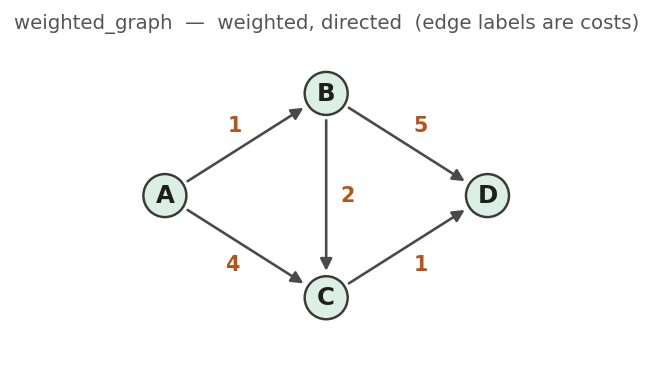

Reading it: every arrow is **one-way** and the orange number on it is that
edge's cost. Note that the cheapest route from A to D is *not* the one with the
fewest arrows &mdash; that is exactly the point Uniform Cost Search makes in Part&nbsp;3.


In [44]:
# ---- Unweighted, undirected graph (adjacency list) :
graph = {
    'A': ['B', 'C'],
    'B': ['A', 'D', 'E'],
    'C': ['A', 'F'],
    'D': ['B'],
    'E': ['B', 'F'],
    'F': ['C', 'E'],
}

# ---- Weighted, directed graph (node -> [(neighbour, cost), ...]) :
weighted_graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('C', 2), ('D', 5)],
    'C': [('D', 1)],
    'D': [],
}

print("Unweighted graph:", list(graph), "| edges:", sum(len(v) for v in graph.values()) // 2)
print("Weighted graph:  ", list(weighted_graph))

Unweighted graph: ['A', 'B', 'C', 'D', 'E', 'F'] | edges: 6
Weighted graph:   ['A', 'B', 'C', 'D']


## Part 1 — Breadth-First Search using a Queue

**Learning aim:** understand *why* BFS needs a **queue (first-in, first-out)** so that nodes are explored level by level, closest-first.

BFS keeps a **frontier** of discovered-but-not-yet-expanded nodes in a **FIFO queue**. Because nodes leave the queue in the same order they entered, every node at distance *d* from the source is expanded before any node at distance *d + 1*. That ordering is exactly what lets BFS return a path with the **fewest edges**.


Implement two functions:
1. **`bfs(graph, source)`** — return the list of nodes in the order they are **dequeued** (visited).
2. **`bfs_shortest_path(graph, source, goal)`** — return the shortest path (fewest edges) as a list of nodes, or `None` if the goal is unreachable.



In [45]:
def bfs(graph, source):
    visited = {source}
    queue = deque([source])
    order = []
    while queue:
        node = queue.popleft()
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                visited.add(neighbour)
                queue.append(neighbour)
    return order


def bfs_shortest_path(graph, source, goal):
    if source == goal:
        return [source]
    visited = {source}
    queue = deque([[source]])
    while queue:
        path = queue.popleft()
        node = path[-1]
        for neighbour in graph[node]:
            if neighbour not in visited:
                new_path = path + [neighbour]
                if neighbour == goal:
                    return new_path
                visited.add(neighbour)
                queue.append(new_path)
    return None

In [46]:
# ---- Self-check
assert bfs(graph, 'A') == ['A', 'B', 'C', 'D', 'E', 'F'], bfs(graph, 'A')
assert bfs(graph, 'C') == ['C', 'A', 'F', 'B', 'E', 'D'], bfs(graph, 'C')
assert bfs_shortest_path(graph, 'A', 'F') == ['A', 'C', 'F']
assert bfs_shortest_path(graph, 'D', 'F') == ['D', 'B', 'E', 'F']
assert bfs_shortest_path(graph, 'A', 'A') == ['A']
print("BFS self-check PASSED")

BFS self-check PASSED


## Part 2 — Depth-First Search using a Stack

**Learning aim:** understand DFS by driving the frontier with a **stack (last-in, first-out)** — and see how swapping the queue for a stack is the *only* change that turns BFS into DFS.

DFS dives as deep as possible before backtracking. Iteratively, the frontier is a **LIFO stack**: the most recently discovered node is expanded next.
Two different implementation of DFS :
1. **`dfs_iterative(graph, source)`** — using an **explicit** list as a stack (`append()` to push, `pop()` to pop). *No recursion.*
2. **`dfs_recursive(graph, source)`** — using recursion, which hides the same stack inside Python's call stack.


In [47]:
def dfs_iterative(graph, source):
    stack = [source]
    visited = set()
    order = []
    while stack:
        node = stack.pop()
        if node in visited:
            continue
        visited.add(node)
        order.append(node)
        for neighbour in graph[node]:
            if neighbour not in visited:
                stack.append(neighbour)
    return order


def dfs_recursive(graph, source, visited=None):
    if visited is None:
        visited = set()
    visited.add(source)
    order = [source]
    for neighbour in graph[source]:
        if neighbour not in visited:
            order.extend(dfs_recursive(graph, neighbour, visited))
    return order

In [48]:
# ---- Self-check ----
it  = dfs_iterative(graph, 'A')
rec = dfs_recursive(graph, 'A')
assert it  == ['A', 'C', 'F', 'E', 'B', 'D'], it
assert rec == ['A', 'B', 'D', 'E', 'F', 'C'], rec
assert dfs_iterative(graph, 'B') == ['B', 'E', 'F', 'C', 'A', 'D']
assert dfs_recursive(graph, 'B') == ['B', 'A', 'C', 'F', 'E', 'D']

# Both are valid DFS orders:
print("Iterative (explicit stack):", it)
print("Recursive (call stack):    ", rec)
print("Same nodes:", set(it) == set(rec), "| Same order:", it == rec)
print("DFS self-check PASSED")

Iterative (explicit stack): ['A', 'C', 'F', 'E', 'B', 'D']
Recursive (call stack):     ['A', 'B', 'D', 'E', 'F', 'C']
Same nodes: True | Same order: False
DFS self-check PASSED


## Part 3 — Uniform Cost Search using a Priority Queue

**Learning aim:** generalise the queue idea to a **priority queue** ordered by *cumulative path cost*, so the cheapest frontier node is always expanded first.

UCS is BFS for **weighted** graphs. Instead of a plain FIFO queue it uses a **min-priority queue** (`heapq`) keyed on the cost-so-far *g(n)*, always popping the cheapest partial path. Because edge costs are non-negative, the **first time a node is popped its cheapest cost is final** — so we test for the goal **when we pop it**, not when we generate it. That single detail is what guarantees UCS returns an optimal (least-cost) path.

Note the trap in `weighted_graph`: the direct edge `A -> C` costs **4**, but `A -> B -> C` costs only **1 + 2 = 3**, and `A -> B -> C -> D` (total **4**) beats both `A -> C -> D` (5) and `A -> B -> D` (6). A correct UCS finds the cost-4 route to `D`.


Implement **`ucs(graph, source, goal)`** returning `(total_cost, path)` for the cheapest route, or `(None, None)` if the goal is unreachable.

In [49]:
def ucs(graph, source, goal):
    frontier = [(0, source, [source])]
    visited = set()
    while frontier:
        cost, node, path = heapq.heappop(frontier)
        if node == goal:
            return (cost, path)
        if node in visited:
            continue
        visited.add(node)
        for neighbour, w in graph[node]:
            if neighbour not in visited:
                heapq.heappush(frontier, (cost + w, neighbour, path + [neighbour]))
    return (None, None)

In [50]:
# ---- Self-check  ----
assert ucs(weighted_graph, 'A', 'D') == (4, ['A', 'B', 'C', 'D']), ucs(weighted_graph, 'A', 'D')
assert ucs(weighted_graph, 'A', 'C') == (3, ['A', 'B', 'C'])
assert ucs(weighted_graph, 'A', 'B') == (1, ['A', 'B'])
assert ucs(weighted_graph, 'B', 'A') == (None, None)   # directed graph: A is unreachable from B
print("UCS self-check PASSED")

UCS self-check PASSED


## Part 4 — Depth-Limited Search

**Learning aim:** control DFS with a depth bound, and learn to distinguish *"the goal isn't there"* from *"we stopped too early."*

DLS is DFS with a maximum depth **L**: it never expands nodes deeper than L (the source is at depth 0). This bounds time and memory but gives up completeness — a goal deeper than L is missed. The key design point is the **two distinct failure signals**:

| Return value | Meaning |
|---|---|
| a list (the path) | goal found within the limit |
| `'cutoff'` | the depth limit stopped the search **while deeper nodes remained** — the goal *might* still exist beyond L |
| `'failure'` | every reachable node within the limit was explored and **none was cut** — the goal is genuinely unreachable |

This distinction is not academic: **IDS (Part 5) depends on it** to decide whether searching one level deeper could still help.


Implement **`dls(graph, node, goal, limit)`** returning a path, `'cutoff'`, or `'failure'`.

In [51]:
def dls(graph, node, goal, limit, path=None):
    if path is None:
        path = [node]
    if node == goal:
        return path
    if limit <= 0:
        return 'cutoff'
    cutoff_occurred = False
    for neighbour in graph[node]:
        if neighbour not in path:
            result = dls(graph, neighbour, goal, limit - 1, path + [neighbour])
            if result == 'cutoff':
                cutoff_occurred = True
            elif result != 'failure':
                return result
    return 'cutoff' if cutoff_occurred else 'failure'

In [52]:
# ---- Self-check  ----
assert dls(graph, 'A', 'F', 1)  == 'cutoff'
assert dls(graph, 'A', 'F', 2)  == ['A', 'C', 'F'], dls(graph, 'A', 'F', 2)
assert dls(graph, 'A', 'D', 3)  == ['A', 'B', 'D']
assert dls(graph, 'A', 'Z', 2)  == 'cutoff'      # 'Z' absent, but the limit stops us first
assert dls(graph, 'A', 'Z', 10) == 'failure'     # fully explored, never cut -> failure
print("DLS self-check PASSED")

DLS self-check PASSED


## Part 5 — Iterative Deepening Search

**Learning aim:** combine DLS with an increasing limit to get **DFS-like memory** with **BFS-like completeness and shallowest-goal optimality**.

IDS simply runs DLS with `limit = 0, 1, 2, ...` until the goal is found. It sounds wasteful — shallow nodes are regenerated on every pass — but because the number of nodes grows exponentially with depth, the **deepest level dominates** the total work, so the repeated shallow expansions add only a constant-factor overhead. In exchange, IDS holds only a **single root-to-leaf path** in memory (like DFS) while still finding the **shallowest** goal first (like BFS).


Implement **`ids(graph, source, goal, max_depth=10)`** on top of  `dls()`. Return `(path, limit_found)` on success, or `(None, None)` if the goal isn't found by `max_depth`.

In [53]:
def ids(graph, source, goal, max_depth=10):
    for limit in range(max_depth + 1):
        result = dls(graph, source, goal, limit)
        if result not in ('cutoff', 'failure'):
            return (result, limit)
    return (None, None)

In [54]:
# ---- Self-check  ----
assert ids(graph, 'A', 'F', 5) == (['A', 'C', 'F'], 2), ids(graph, 'A', 'F', 5)
assert ids(graph, 'A', 'D', 5) == (['A', 'B', 'D'], 2)
assert ids(graph, 'A', 'A', 5) == (['A'], 0)
assert ids(graph, 'A', 'Z', 5) == (None, None)
print("IDS self-check PASSED")

IDS self-check PASSED


## Part 6 — Putting It All Together

Run all five algorithms togethem to see them side by side on the shared graphs:
- **BFS** and **DFS** visit the *same six nodes* in *different orders* (queue vs stack).
- **UCS** returns the least-*cost* path on the weighted graph — not the fewest-*edges* one.
- **DLS** and **IDS** find the same path to `F`; IDS reports the shallowest depth at which it appears.

In [55]:

try:
    rows = []
    rows.append(("BFS visit order  (A)",      bfs(graph, 'A'), "-"))
    rows.append(("BFS path  A -> F",          bfs_shortest_path(graph, 'A', 'F'), "-"))
    rows.append(("DFS iterative order (A)",   dfs_iterative(graph, 'A'), "-"))
    rows.append(("DFS recursive order (A)",   dfs_recursive(graph, 'A'), "-"))
    cost, p = ucs(weighted_graph, 'A', 'D')
    rows.append(("UCS  A -> D",               p, cost))
    rows.append(("DLS  A -> F (limit 2)",     dls(graph, 'A', 'F', 2), "-"))
    path, lim = ids(graph, 'A', 'F', 5)
    rows.append(("IDS  A -> F (found @ %s)" % lim, path, "-"))

    print(f"{'Query':<28} | {'Result path / order':<32} | {'Cost'}")
    print("-" * 74)
    for label, res, cost in rows:
        print(f"{label:<28} | {str(res):<32} | {cost}")
except (TypeError, ValueError, NotImplementedError) as e:
    print("(", type(e).__name__, ")")

Query                        | Result path / order              | Cost
--------------------------------------------------------------------------
BFS visit order  (A)         | ['A', 'B', 'C', 'D', 'E', 'F']   | -
BFS path  A -> F             | ['A', 'C', 'F']                  | -
DFS iterative order (A)      | ['A', 'C', 'F', 'E', 'B', 'D']   | -
DFS recursive order (A)      | ['A', 'B', 'D', 'E', 'F', 'C']   | -
UCS  A -> D                  | ['A', 'B', 'C', 'D']             | 4
DLS  A -> F (limit 2)        | ['A', 'C', 'F']                  | -
IDS  A -> F (found @ 2)      | ['A', 'C', 'F']                  | -
